#Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')


import pandas as pd
import numpy as np
from plotnine import *
import re
import matplotlib.pyplot as plt

# modelling
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelBinarizer #Z-score variables
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor # Decision Tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor # random forest
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor # gradient boosting
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.naive_bayes import GaussianNB
from sklearn.compose import ColumnTransformer
from sklearn.cluster import DBSCAN

# performance
from sklearn.metrics import accuracy_score, confusion_matrix,\
 f1_score, recall_score, precision_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.calibration import calibration_curve
from sklearn.metrics import silhouette_score

# model validation imports
from sklearn.model_selection import train_test_split # simple TT split cv
from sklearn.model_selection import KFold # k-fold cv
from sklearn.model_selection import LeaveOneOut #LOO cv

# pipeline imports
from sklearn.metrics import accuracy_score, confusion_matrix,\
 f1_score, recall_score, precision_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer

In [ ]:
data = pd.read_csv("/content/Crime_Data_2010_2017.csv")

#Question 1

##Preprocessing and filtering

In [ ]:
data.dropna(subset=["Crime Code Description"], inplace=True)
data.reset_index(inplace = True)
data.head()

,index,DR Number,Date Reported,Date Occurred,Time Occurred,Area ID,Area Name,Reporting District,Crime Code,Crime Code Description,...,Weapon Description,Status Code,Status Description,Crime Code 1,Crime Code 2,Crime Code 3,Crime Code 4,Address,Cross Street,Location
0,0,1208575,03/14/2013,03/11/2013,1800,12,77th Street,1241,626,INTIMATE PARTNER - SIMPLE ASSAULT,...,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AO,Adult Other,626.0,NaN,NaN,NaN,6300 BRYNHURST AV,NaN,"(33.9829, -118.3338)"
1,1,102005556,01/25/2010,01/22/2010,2300,20,Olympic,2071,510,VEHICLE - STOLEN,...,NaN,IC,Invest Cont,510.0,NaN,NaN,NaN,VAN NESS,15TH,"(34.0454, -118.3157)"
2,2,418,03/19/2013,03/18/2013,2030,18,Southeast,1823,510,VEHICLE - STOLEN,...,NaN,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E 104TH ST,NaN,"(33.942, -118.2717)"
3,3,101822289,11/11/2010,11/10/2010,1800,18,Southeast,1803,510,VEHICLE - STOLEN,...,NaN,IC,Invest Cont,510.0,NaN,NaN,NaN,88TH,WALL,"(33.9572, -118.2717)"
4,4,42104479,01/11/2014,01/04/2014,2300,21,Topanga,2133,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,NaN,IC,Invest Cont,745.0,NaN,NaN,NaN,7200 CIRRUS WY,NaN,"(34.2009, -118.6369)"


In [ ]:
filtered = data[data["Crime Code Description"].str.contains(r'\b(BURGLARY|ROBBERY|SHOPLIFTING)\b')]
pd.set_option('display.max_columns', None)

In [ ]:
predictor = ["Time Occurred"]
filtered.dropna(subset=["Crime Code Description"], inplace = True)
X = filtered[predictor]
y = filtered["Crime Code Description"]

## Model Training

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state = 123)

# Create Empty Model
pre = make_column_transformer((StandardScaler(), predictor),
                              remainder = "passthrough")
tree = DecisionTreeClassifier(random_state = 1234)

pipe = Pipeline([("pre", pre), ("tree", tree)])

# fit
pipe.fit(X_train, y_train)

# predict

y_pred_train = pipe.predict(X_train)
y_pred_test = pipe.predict(X_test)

y_pred_train_prob = pipe.predict_proba(X_train)[:,1]
y_pred_test_prob = pipe.predict_proba(X_test)[:,1]



## Model Performance

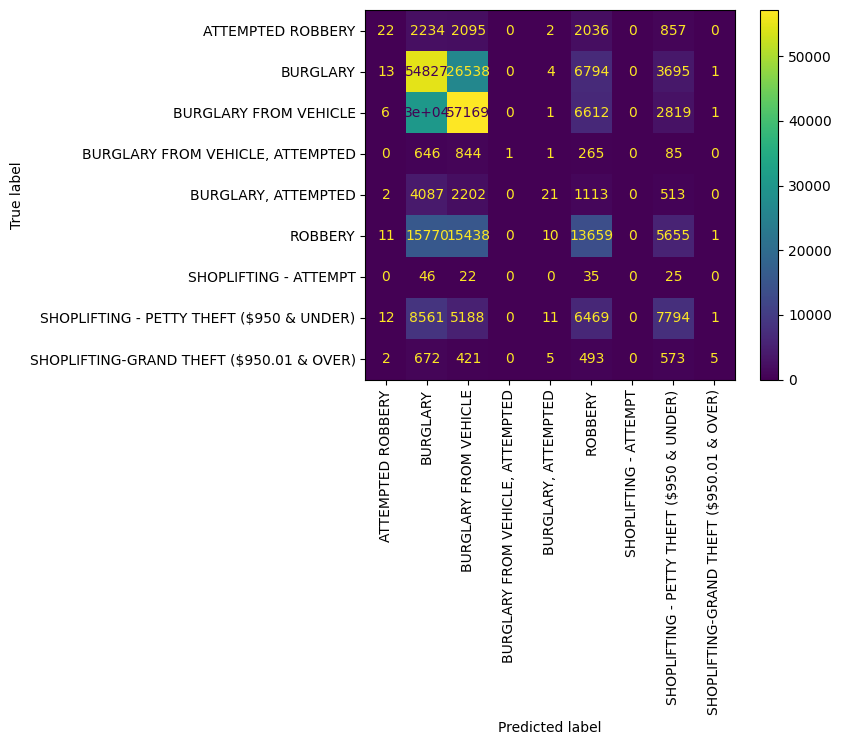

In [ ]:
print(ConfusionMatrixDisplay.from_predictions(y_train, pipe.predict(X_train), xticks_rotation='vertical'))



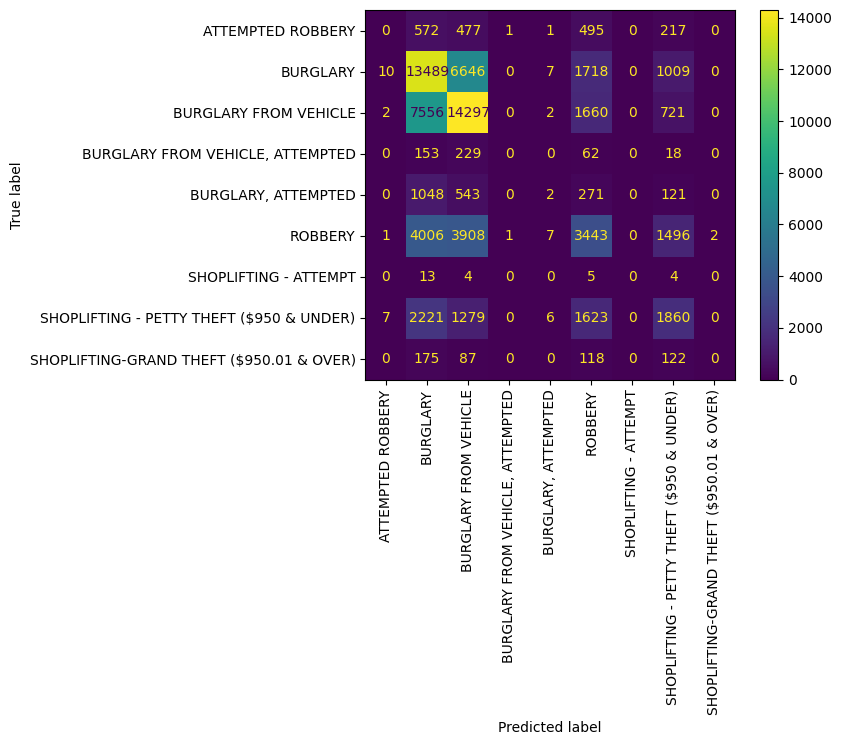

In [ ]:
print(ConfusionMatrixDisplay.from_predictions(y_test, pipe.predict(X_test), xticks_rotation='vertical'))

## Data Analysis Graphs

<Figure size 300x200 with 0 Axes>

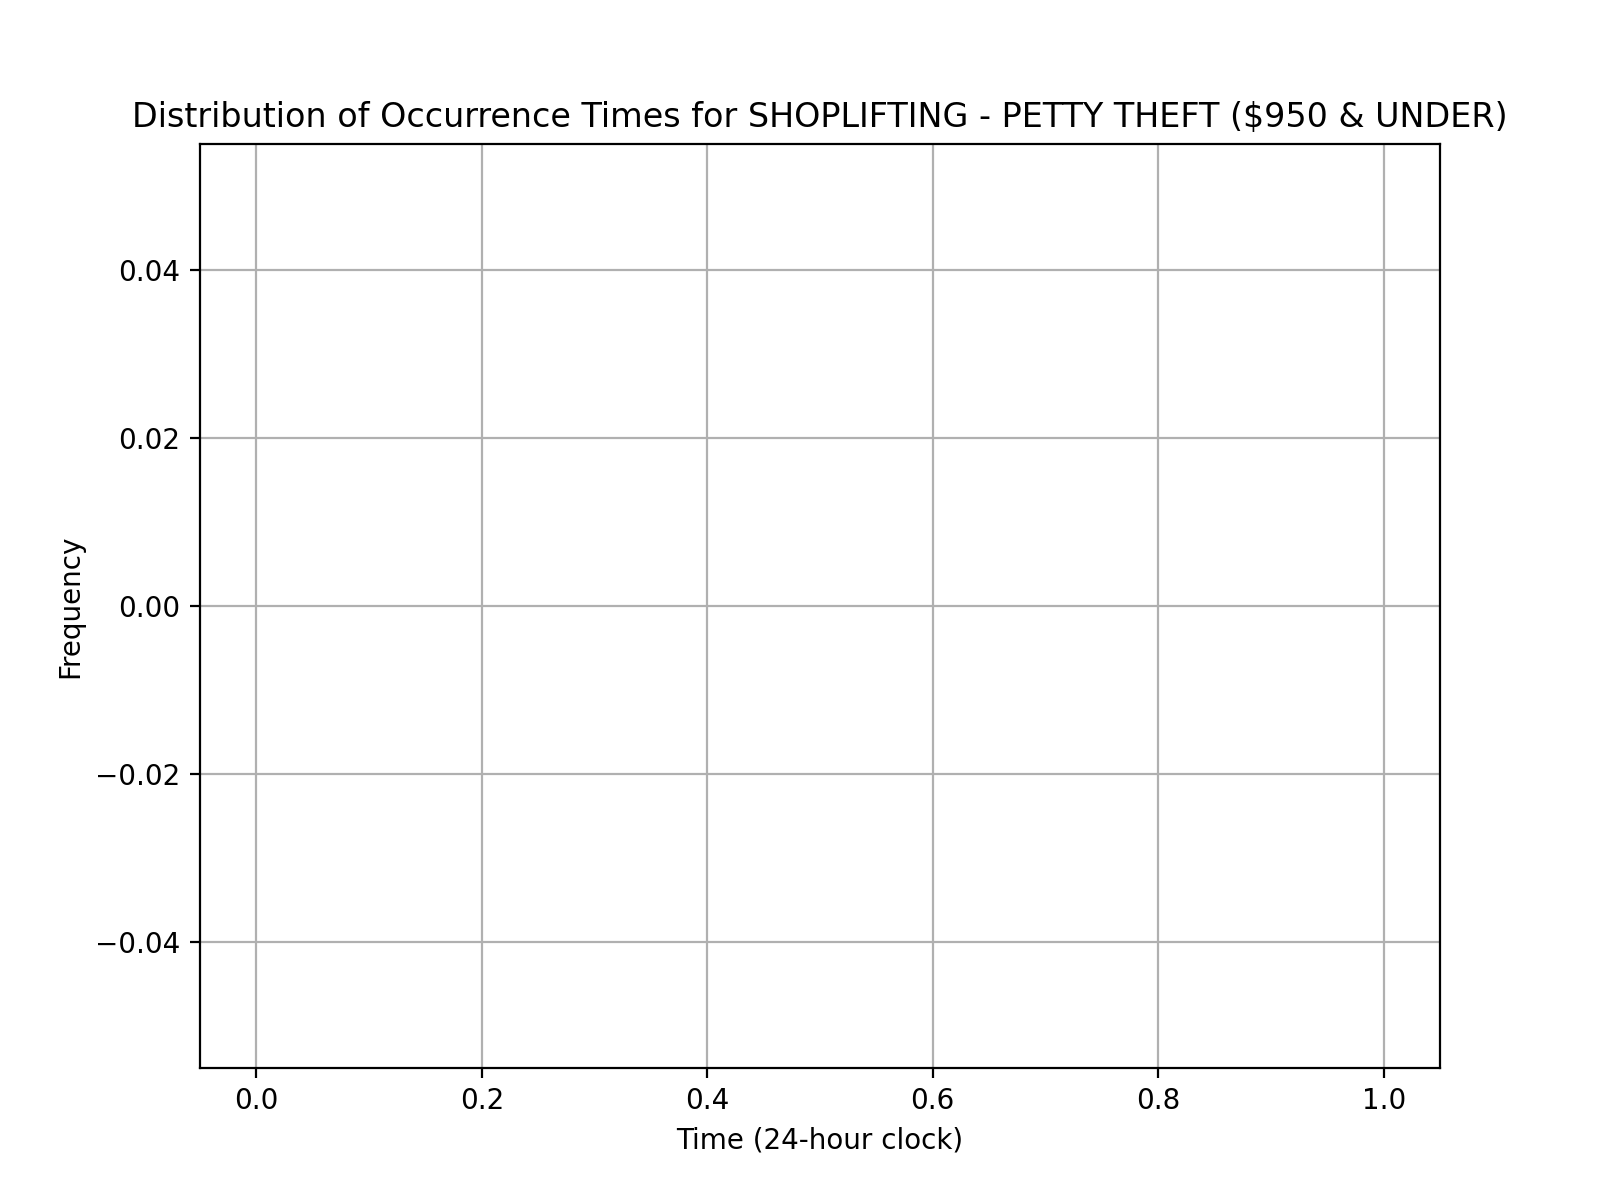

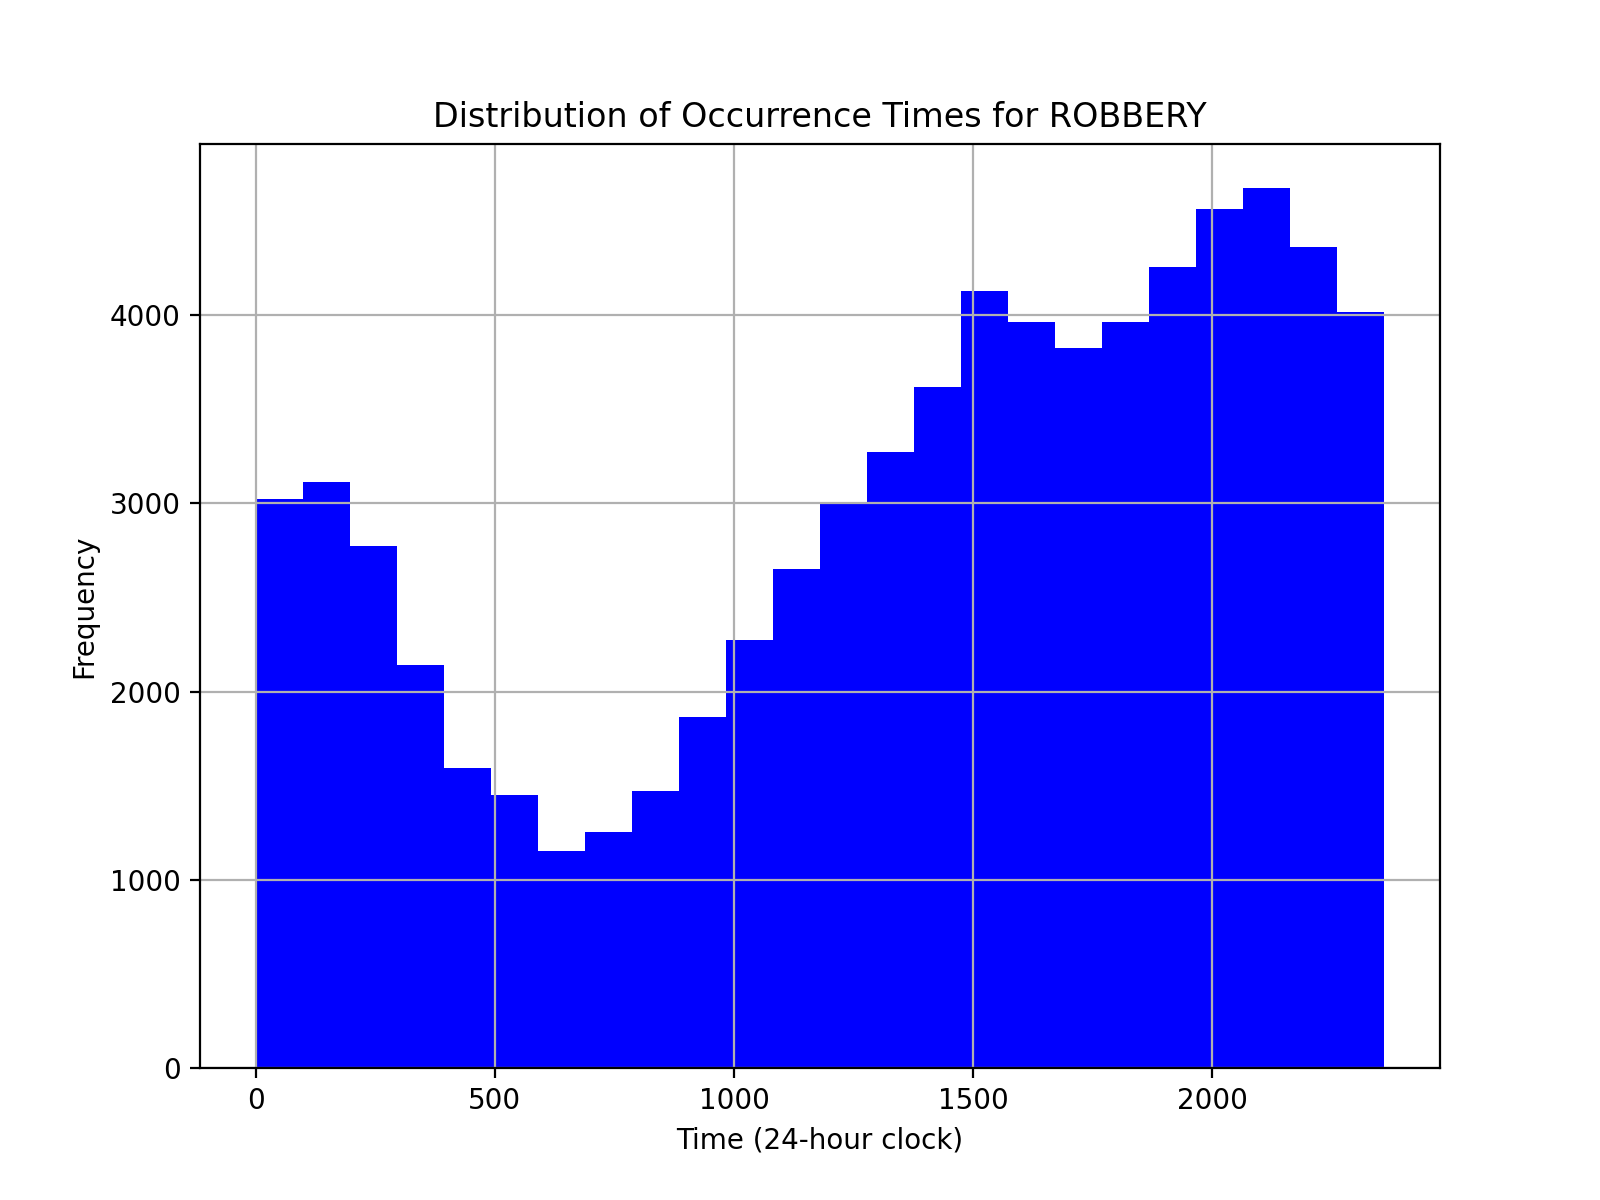

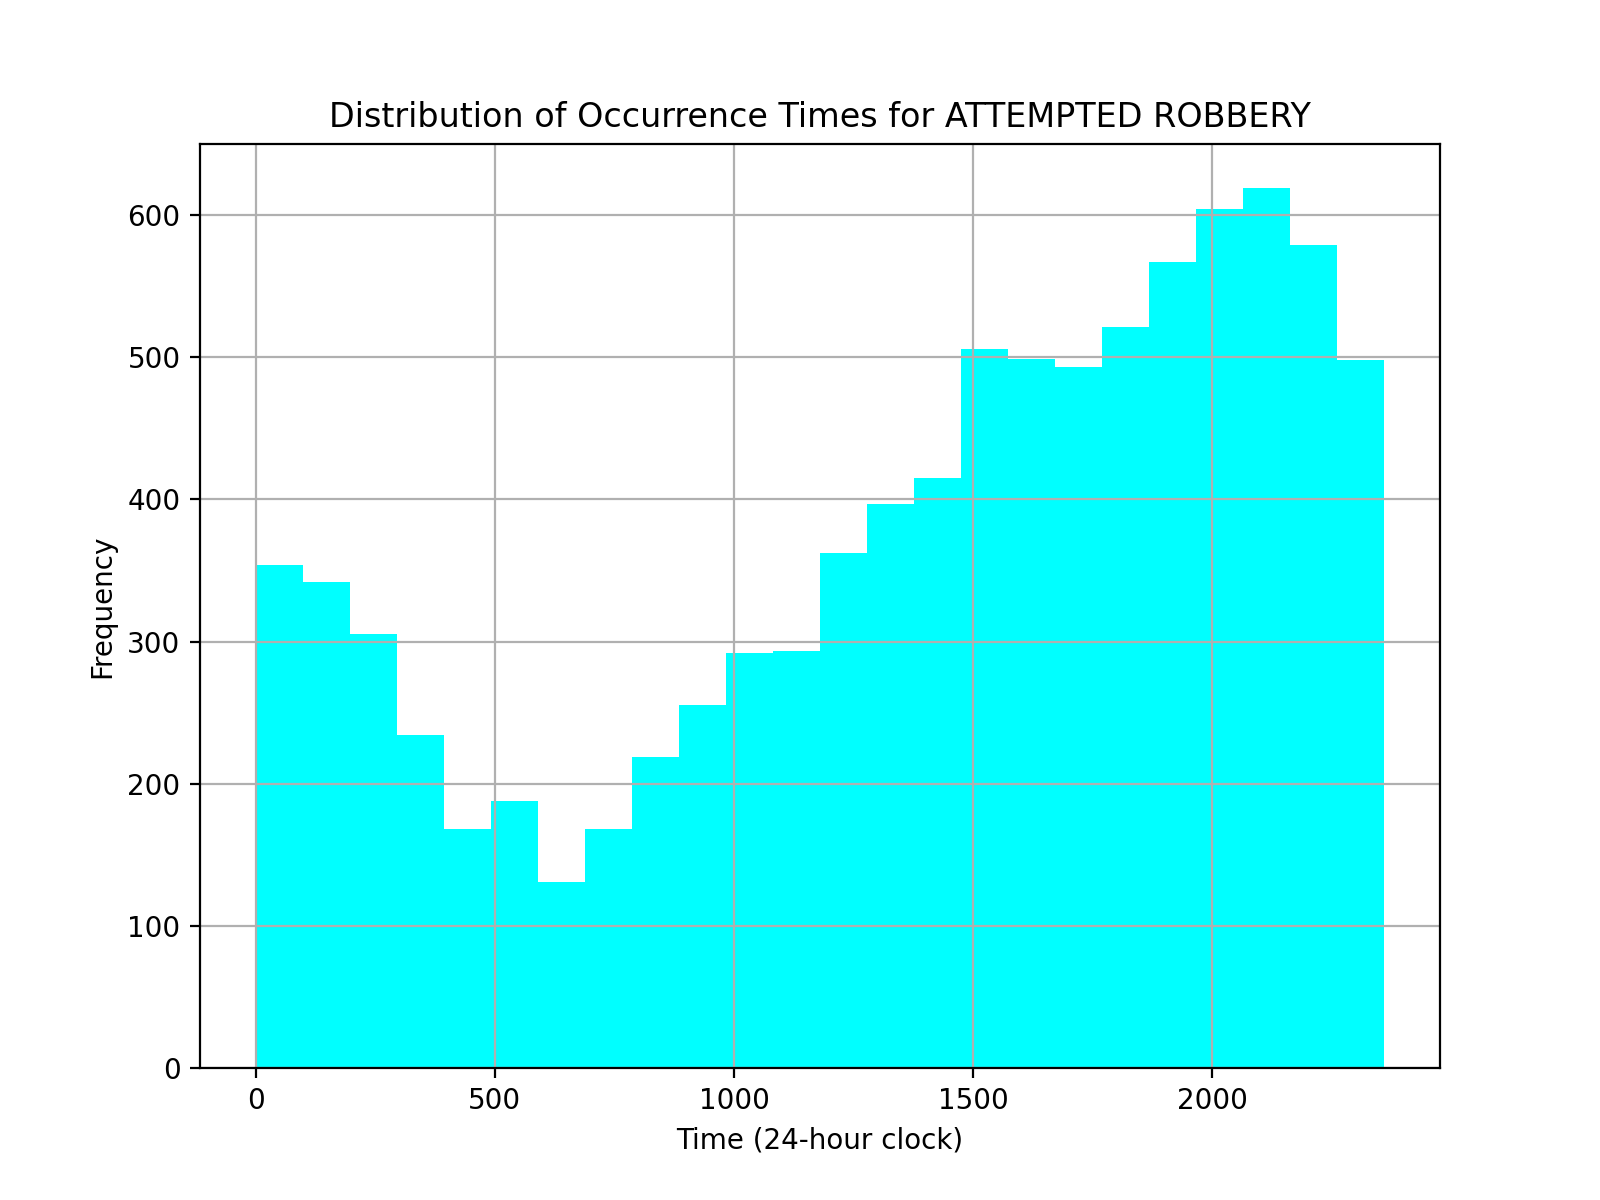

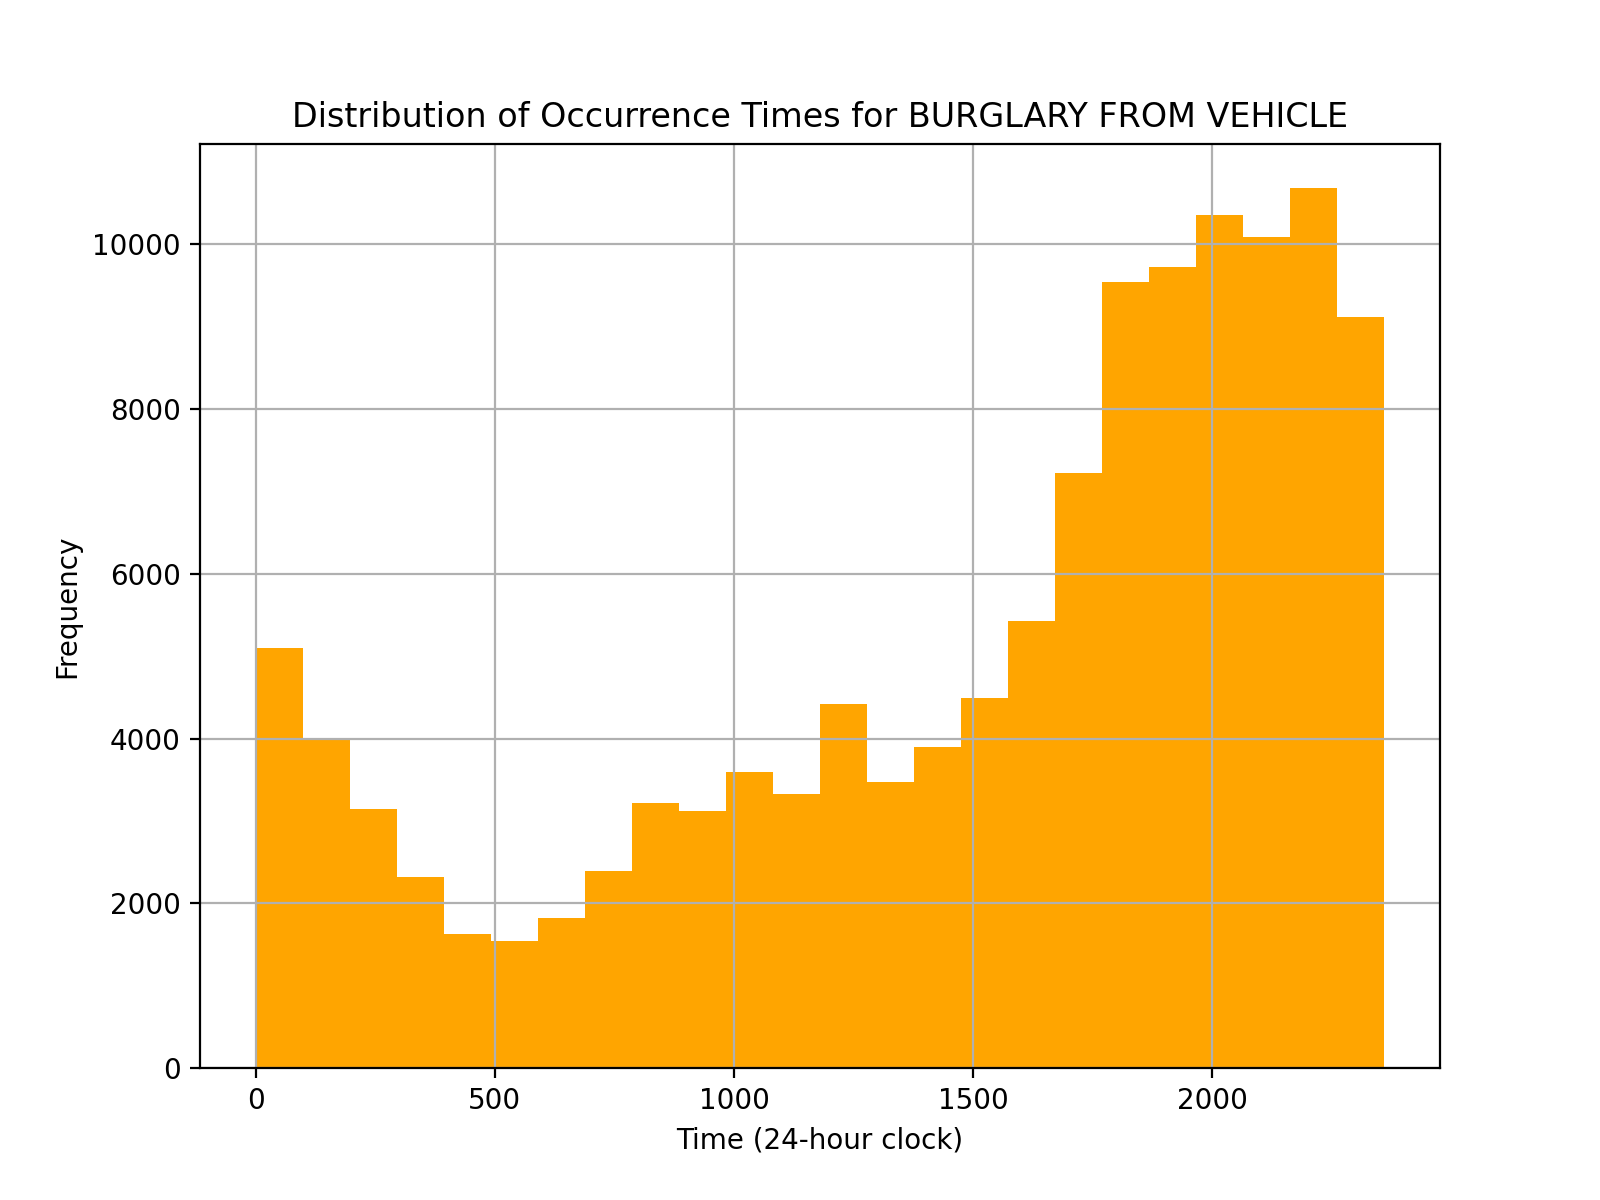

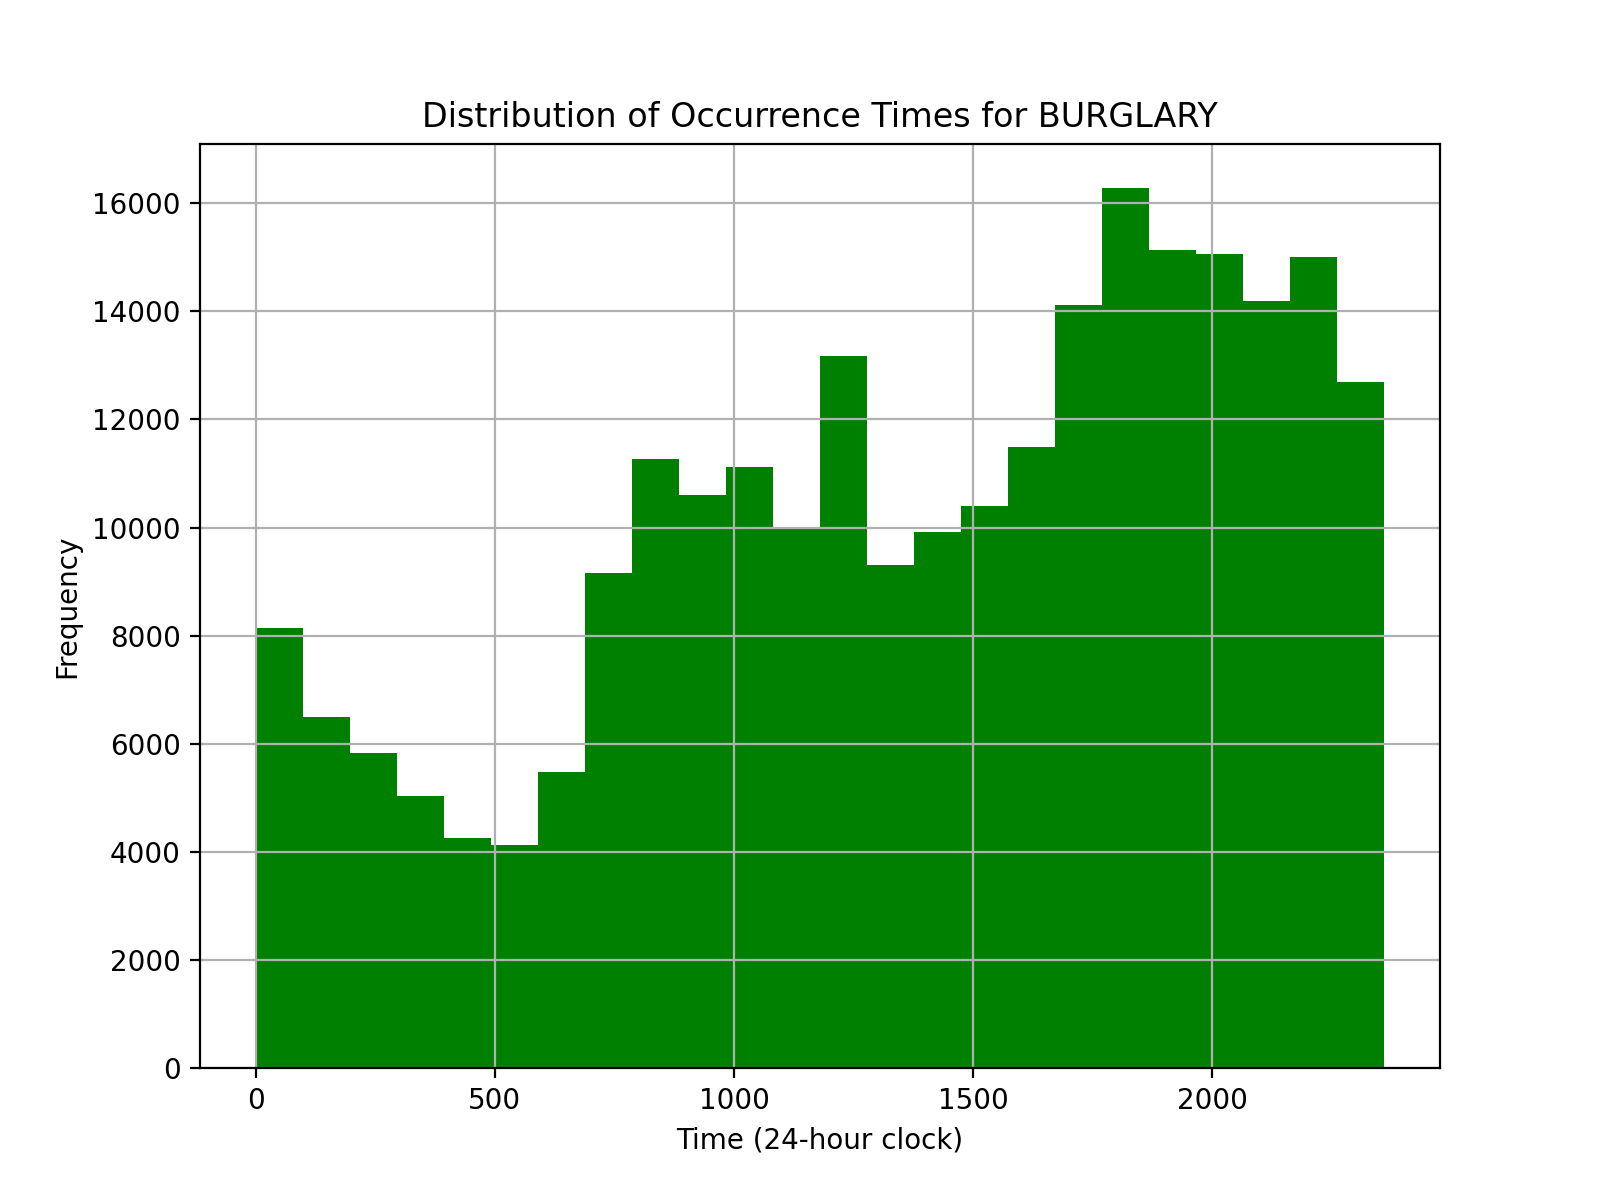

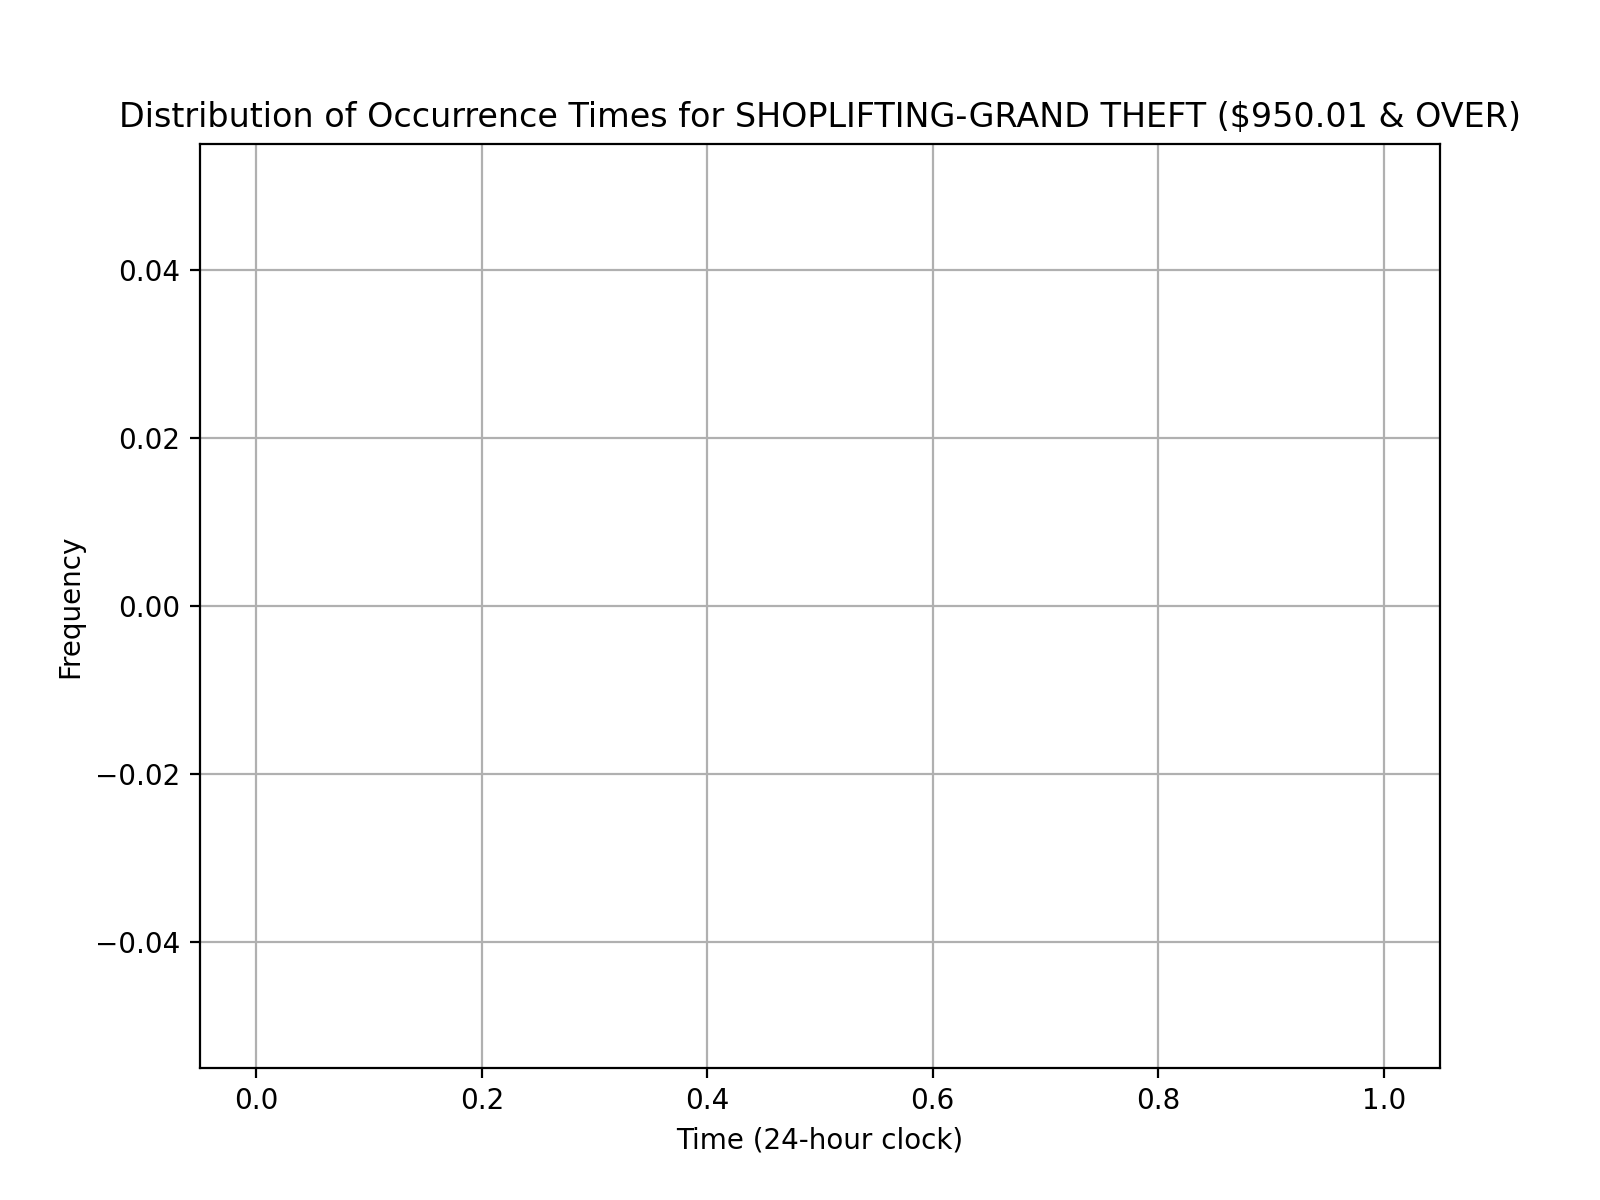

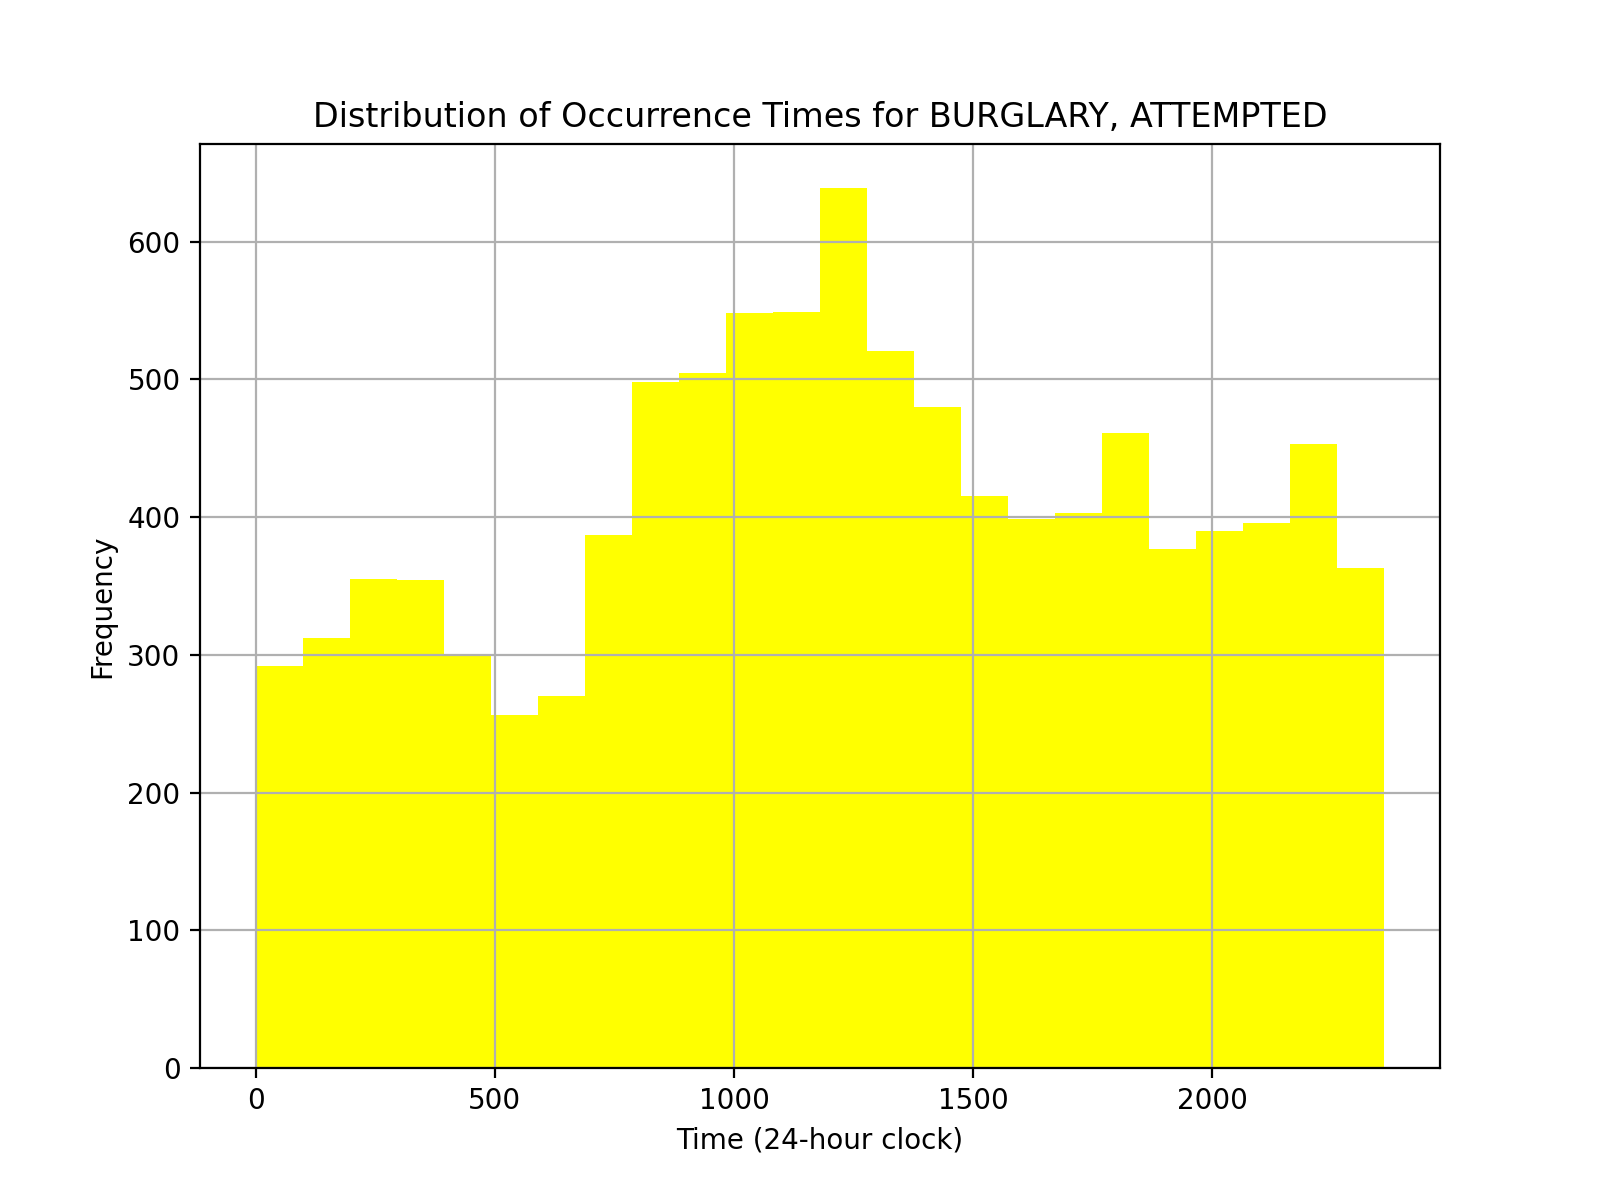

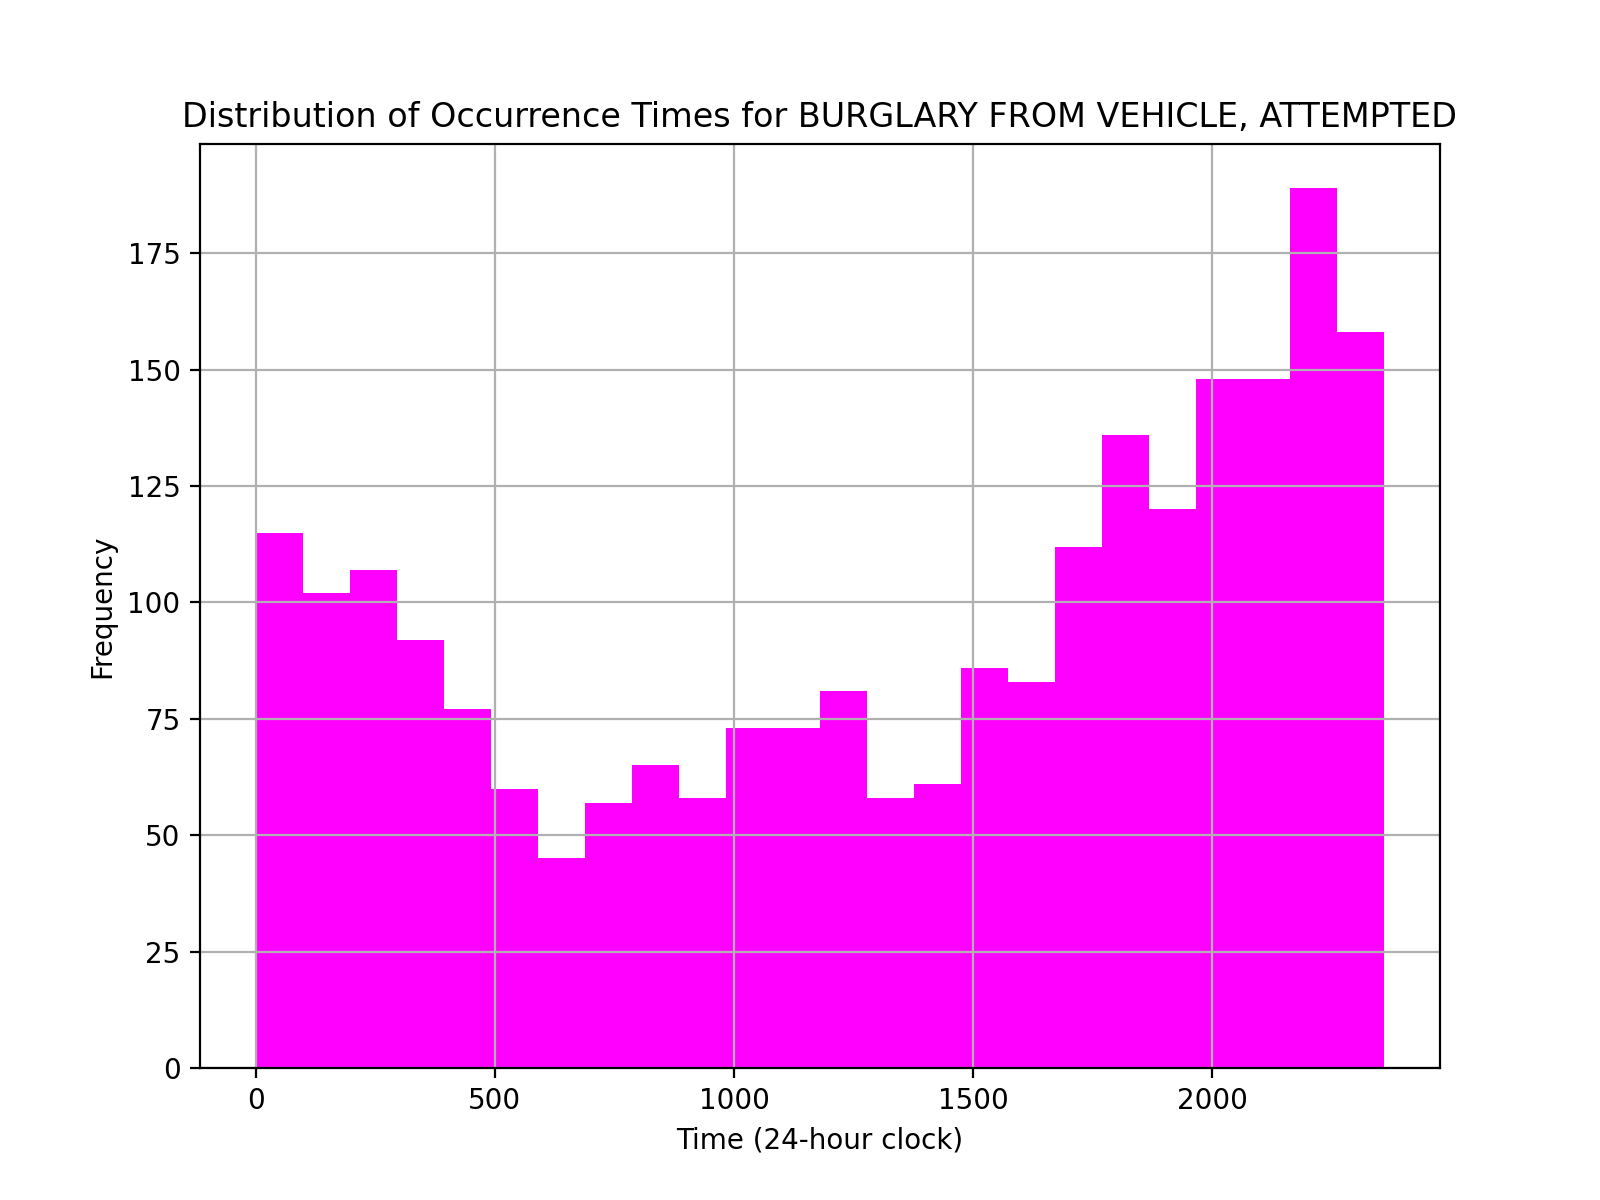

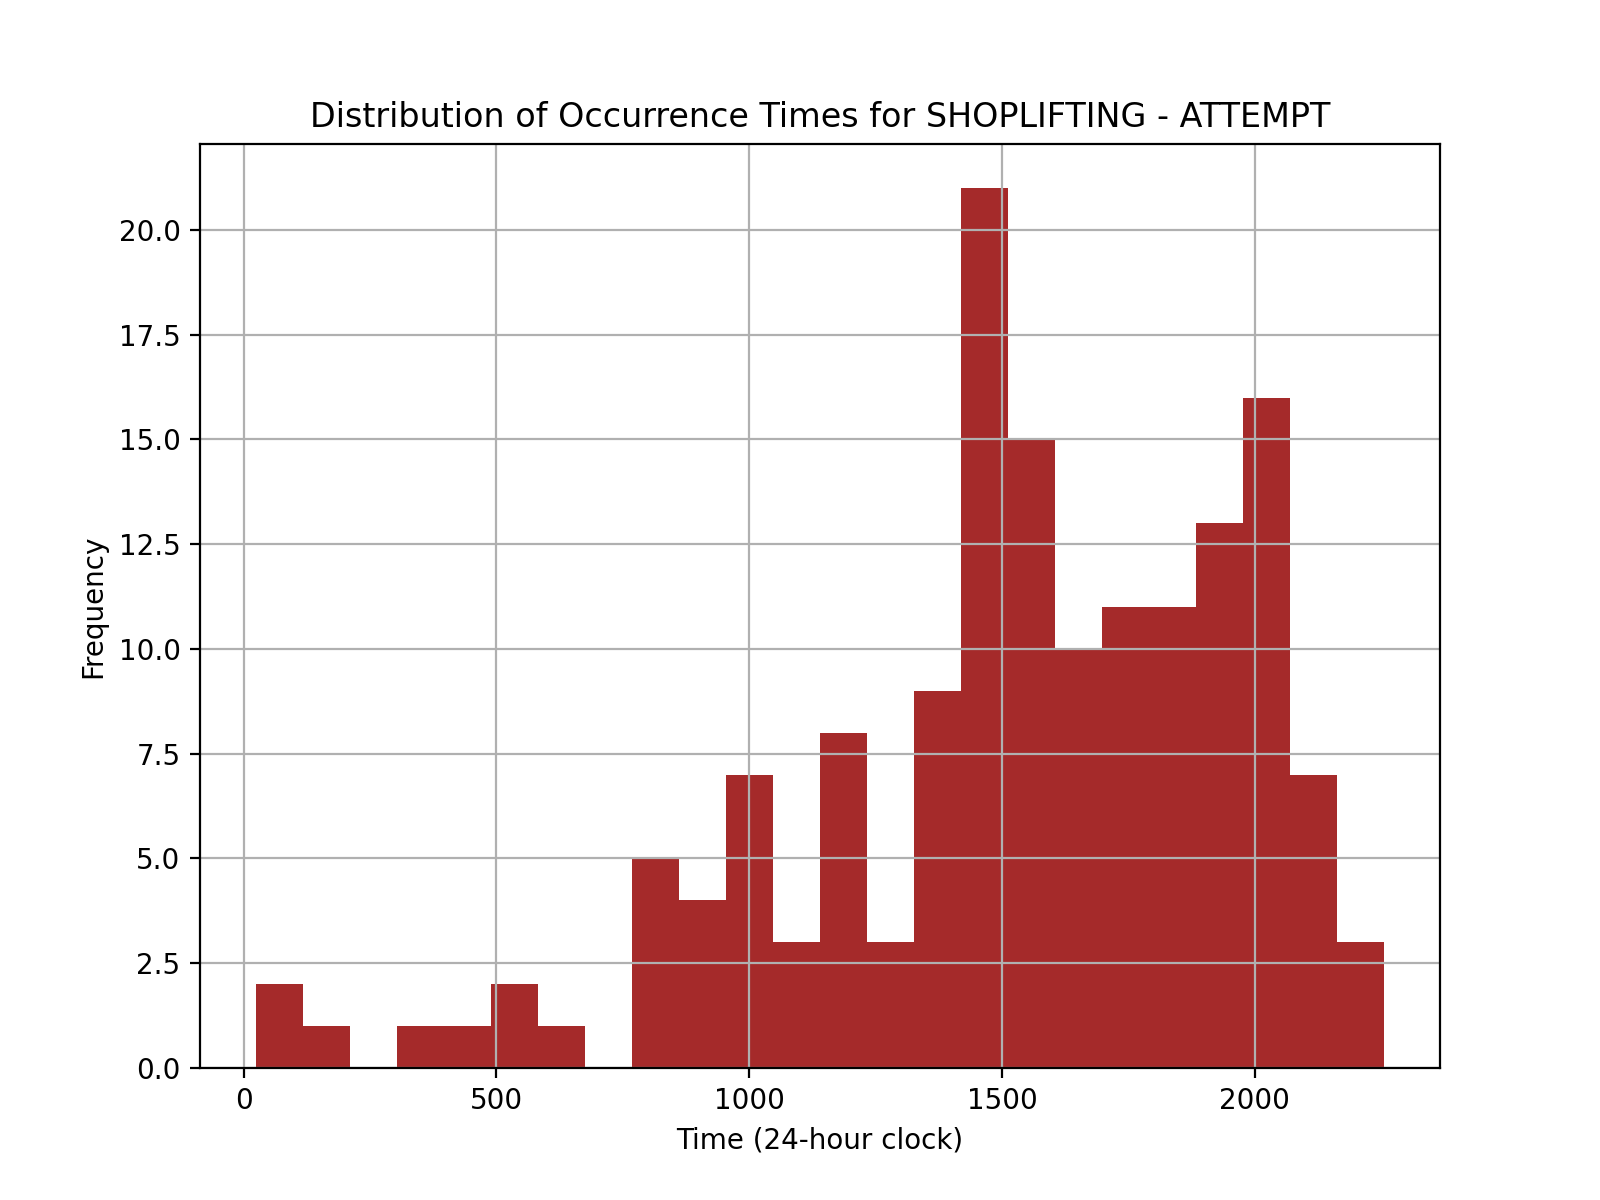

In [ ]:
color_map = {
    'SHOPLIFTING - PETTY THEFT ($950 & UNDER)': 'red',
    'ROBBERY': 'blue',
    'ATTEMPTED ROBBERY': 'cyan',
    'BURGLARY FROM VEHICLE': 'orange',
    'BURGLARY': 'green',
    'SHOPLIFTING-GRAND THEFT ($950.01 & OVER)': 'purple',
    'BURGLARY, ATTEMPTED': 'yellow',
    'BURGLARY FROM VEHICLE, ATTEMPTED': 'magenta',
    'SHOPLIFTING - ATTEMPT': 'brown'
}


# Plot occurrence times for each type of crime code
plt.figure(figsize=(3, 2))


for crime_code, color in color_map.items():
    filtered_subset = filtered[filtered["Crime Code Description"].str.contains(crime_code)]
    plt.figure(figsize=(8, 6))
    plt.hist(filtered_subset["Time Occurred"], bins=24, color=color)
    plt.title(f'Distribution of Occurrence Times for {crime_code}')
    plt.xlabel('Time (24-hour clock)')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

## Model Metrics

In [ ]:
print("Train Acc       : ", accuracy_score(y_train, y_pred_train))
print("Train Prescision: ", precision_score(y_train, y_pred_train, average='weighted'))
print("Train Recall    : ", recall_score(y_train, y_pred_train, average='weighted'))
print("Train F1        : ", f1_score(y_train, y_pred_train, average='weighted'))


print("Test Acc        : ", accuracy_score(y_test, y_pred_test))
print("Test Prescision : ", precision_score(y_test, y_pred_test, average='weighted'))
print("Test Recall     : ", recall_score(y_test, y_pred_test, average='weighted'))
print("Test F1         : ", f1_score(y_test, y_pred_test, average='weighted'))

Train Acc       :  0.4653817058673834
Train Prescision:  0.4538811187313581
Train Recall    :  0.4653817058673834
Train F1        :  0.44028113532046187
Test Acc        :  0.46142369099909364
Test Prescision :  0.42365004888808205
Test Recall     :  0.46142369099909364
Test F1         :  0.4364860143917412


#Question 2

## Filtering and Preprocessing

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
data.dropna(subset=["MO Codes", "Time Occurred", "Area ID", "Date Occurred"], inplace = True)
filtered = data[data["Area ID"] == 1]

In [ ]:
filtered["MO Codes"] = filtered["MO Codes"].str.split()
filtered = filtered.explode("MO Codes").reset_index(drop = True)
filtered.head()

In [ ]:
predictors = ["MO Codes", "Time Occurred", "Date Occurred"]
continous = ["Time Occurred"]
categorical = ["MO Codes", "Date Occurred"]

sampled_data = filtered.sample(n=10000, random_state=42)

X = sampled_data[predictors]
z = make_column_transformer((StandardScaler(), continous),
                            (OneHotEncoder(), categorical),
                              remainder = "passthrough")

## Model Training

In [ ]:

eps = 1
min_samples = 4
db = DBSCAN(eps = eps, min_samples = min_samples)
pipe = Pipeline([("z", z), ("clust", db)])

labels = pipe.fit_predict(X)

X["clusters"] = labels

## Data Analysis Graphs

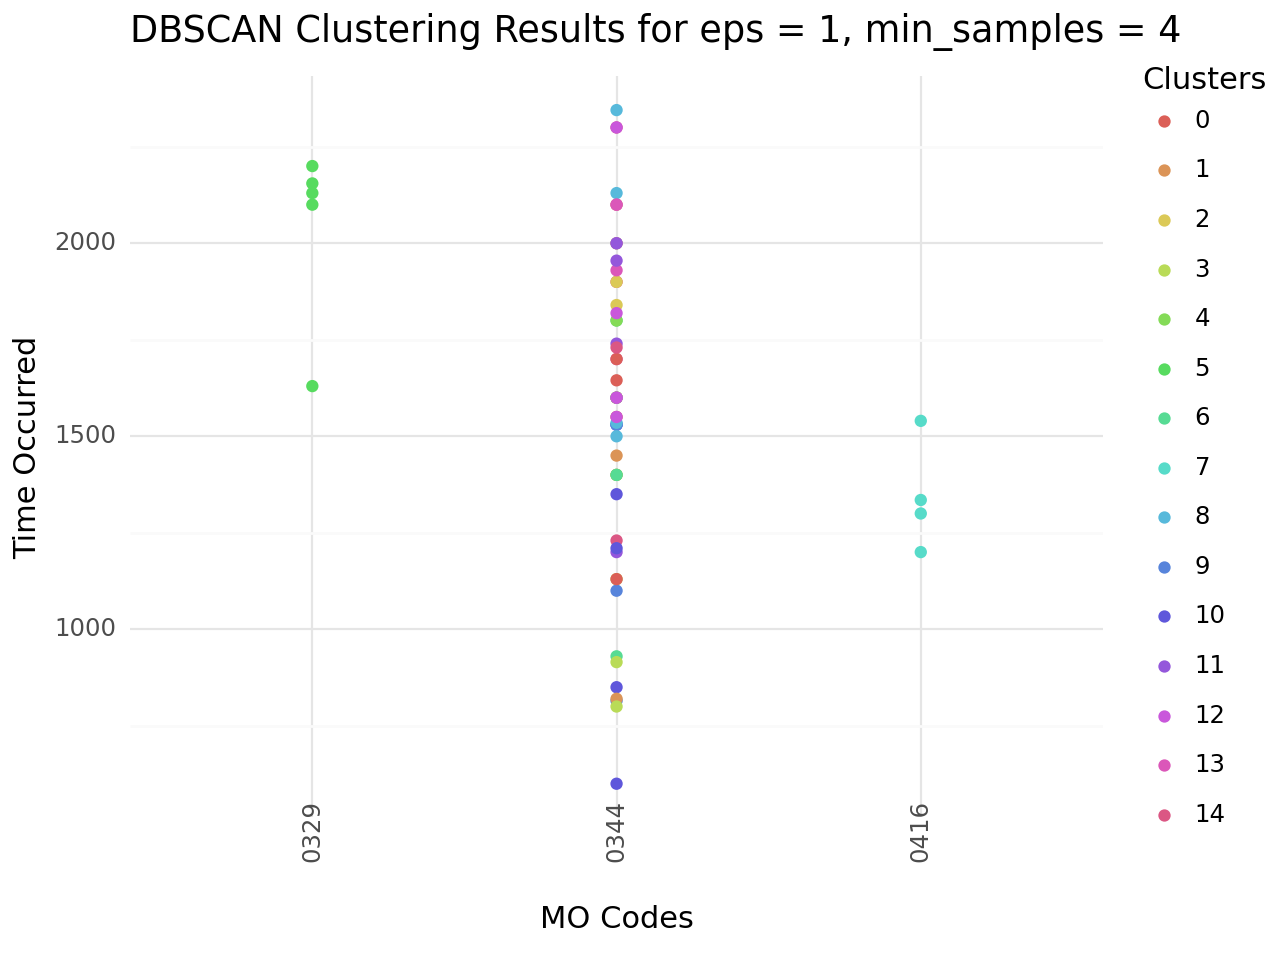

In [ ]:
clustered_data = X[X["clusters"] != -1]
print(ggplot(clustered_data, aes(x = "MO Codes", y = "Time Occurred", color = "factor(clusters)" )) +
      geom_point() + theme_minimal() +
     labs(x = "MO Codes", y = "Time Occurred", title = f"DBSCAN Clustering Results for eps = {eps}, min_samples = {min_samples}",
         color = "Clusters")+ theme(axis_text_x=element_text(angle=90, vjust=0.5)))

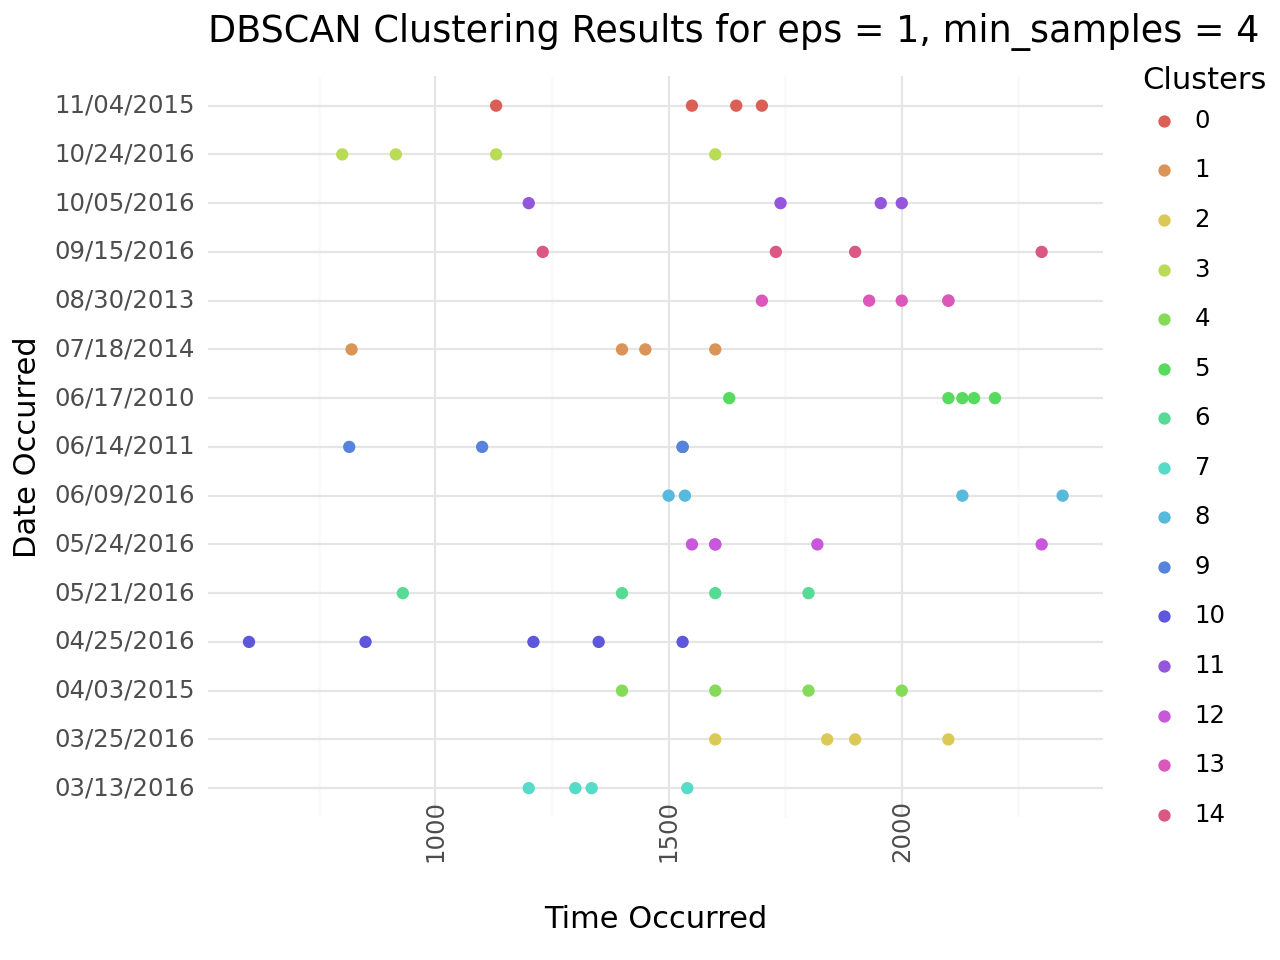

In [ ]:
print(ggplot(clustered_data, aes(x = "Time Occurred", y = "Date Occurred", color = "factor(clusters)" )) +
      geom_point() + theme_minimal() +
     labs(x = "Time Occurred", y = "Date Occurred", title = f"DBSCAN Clustering Results for eps = {eps}, min_samples = {min_samples}",
         color = "Clusters")+ theme(axis_text_x=element_text(angle=90, vjust=0.5)))

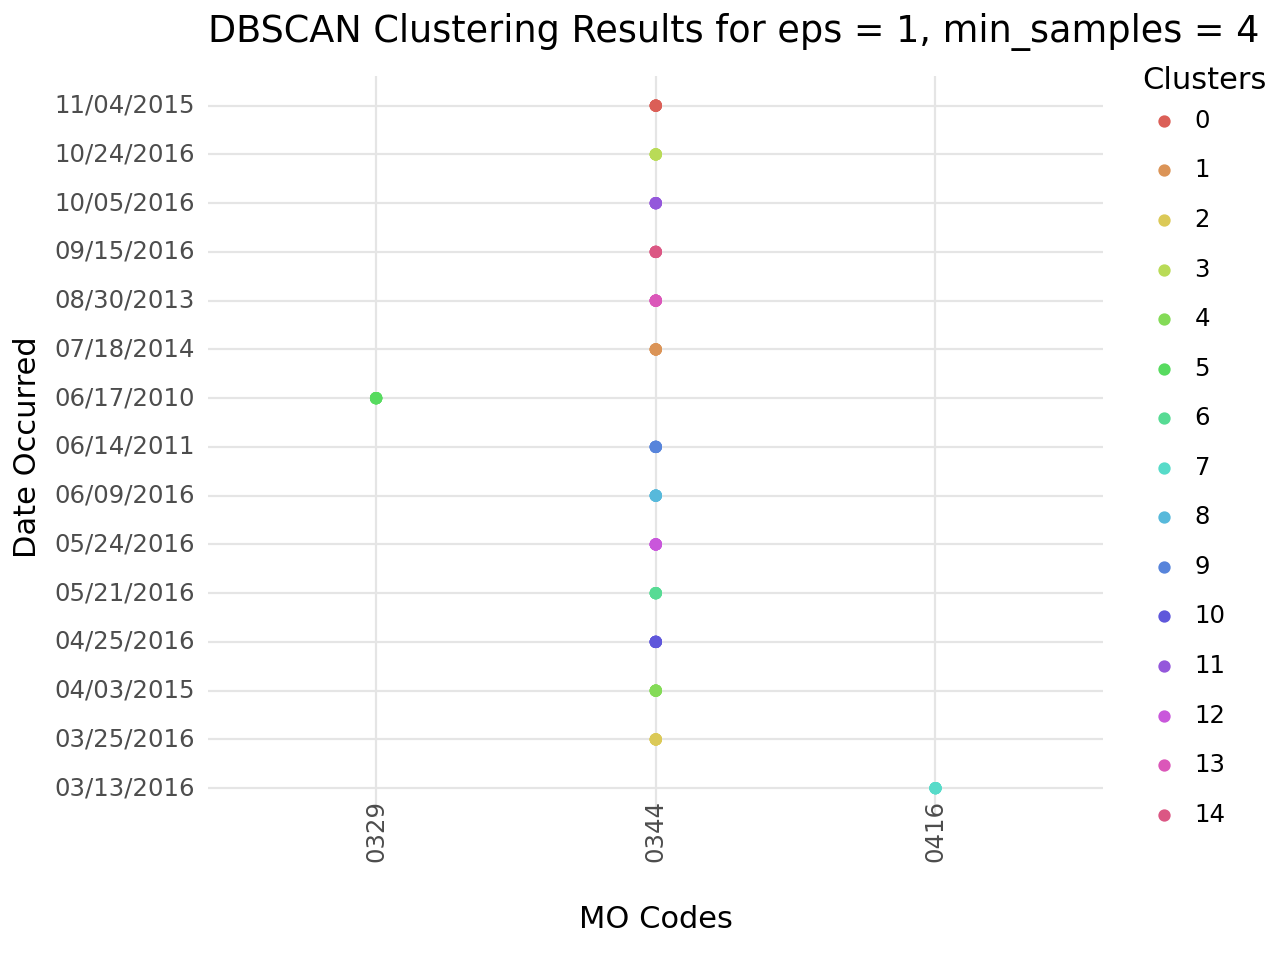

In [ ]:
print(ggplot(clustered_data, aes(x = "MO Codes", y = "Date Occurred", color = "factor(clusters)" )) +
      geom_point() + theme_minimal() +
     labs(x = "MO Codes", y = "Date Occurred", title = f"DBSCAN Clustering Results for eps = {eps}, min_samples = {min_samples}",
         color = "Clusters")+ theme(axis_text_x=element_text(angle=90, vjust=0.5)))

## Model Analysis Metrics

In [ ]:
print(silhouette_score(X[continous], X["clusters"]))

-0.6390657593899762
